In [24]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
import pandas as pd
from scipy.stats import skewnorm
_skg_cache = {}

def skewed_gaussian(x, x0, s, alpha):
    if s <= 0:
        return np.zeros_like(x)
    # use scipy's skew-normal PDF (vectorized and optimized)
    arr = np.array(x)
    raw = skewnorm.pdf(arr, a=alpha, loc=x0, scale=s)

    # cache normalization factor per (x0,s,alpha)
    key = (float(x0), float(s), float(alpha))
    if key not in _skg_cache:
        grid = np.linspace(x0 - 10 * s, x0 + 10 * s, 2001)
        raw_g = skewnorm.pdf(grid, a=alpha, loc=x0, scale=s)
        max_raw = np.max(raw_g)
        _skg_cache[key] = 1.0 / max_raw if max_raw > 0 else 1.0

    return raw * _skg_cache[key]

def profile( de, theta ):
    # Gaussian
    if de <= 0:
        return 0
    else:
        return skewed_gaussian( de, theta["mean"]+theta["dead_layer"], theta["std"], theta.get("alpha", 0.0) )

In [25]:
# Model to recover yield from stoichiometry and 19F profile parameters

from scipy import integrate
from scipy.optimize import curve_fit
from SRIM import SRIM

def model_yield( x, target ):
    # Usefull constants
    k = 8.617e-5            # Boltzmann constant in eV/K
    eff_far = 0.0044        # Far geometry efficiency
    eff_close = 0.689       # Close geometry efficiency
    q_e = 1.602176634e-19   # Charge of the electron in C

    # Define the cross-section
    data = np.loadtxt( f"/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/utils/all_imp.extrap", usecols=(0,3))
    energies, extrap = data[:,0], data[:,1]

    # Doppler effect
    dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

    # Read the element stopping data
    H_in_F = SRIM( "/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/stopping/H_in_F.stop" )
    H_in_H = SRIM( "/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/stopping/H_in_H.stop" )
    H_in_Fe = SRIM( "/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/stopping/H_in_Fe.stop" )
    H_in_Ta = SRIM( "/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/stopping/H_in_Ta.stop" )
    H_in_Ca = SRIM( "/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/stopping/H_in_Ca.stop" )

    # Get the effective stopping power for CaF2
    def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
        stoichiometry = n_inactive / n_active
        return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

    # Get the effective stopping power for F implanted in Fe
    def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
        stoichiometry = n_inactive / n_active
        return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

    # Get the effective stopping power for F implanted in Ta
    def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
        stoichiometry = n_inactive / n_active
        return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

    # Straggling
    popt = [0.75324712]
    def straggling( x ):
        return popt[0] * np.sqrt( x )

    # Profile functions
    def gaussian( x, x0, s ):
        return np.exp( -(x - x0)**2 / ( s*s*2 ) )

    _skg_cache = {}

    def skewed_gaussian(x, x0, s, alpha):
        if s <= 0:
            return np.zeros_like(x)
        # use scipy's skew-normal PDF (vectorized and optimized)
        arr = np.array(x)
        raw = skewnorm.pdf(arr, a=alpha, loc=x0, scale=s)

        # cache normalization factor per (x0,s,alpha)
        key = (float(x0), float(s), float(alpha))
        if key not in _skg_cache:
            grid = np.linspace(x0 - 10 * s, x0 + 10 * s, 2001)
            raw_g = skewnorm.pdf(grid, a=alpha, loc=x0, scale=s)
            max_raw = np.max(raw_g)
            _skg_cache[key] = 1.0 / max_raw if max_raw > 0 else 1.0

        return raw * _skg_cache[key]

    def profile( de, theta, target_type ):
        if target_type == 'implanted':
            # Gaussian
            if de <= 0:
                return 0
            else:
                return skewed_gaussian( de, theta["mean"], theta["std"], theta["alpha"] )
                # return gaussian( de, theta["mean"]+theta["dead_layer"], theta["std"] )
        elif target_type == 'fluorinated':
            if de > 0 and de < theta["width1"]:
                return 1 #- ( de / theta["width"] )*0.4
            elif de > theta["width1"] and de < theta["width2"] + theta["width1"]:
                return theta["norm1"]
            elif de > theta["width2"] + theta["width1"] and de < theta["width2"] + theta["width1"] + theta["width3"]:
                # return 0.09
                return theta["norm2"] #2.5/de
            else:
                return 0
        elif target_type == 'evaporated':
            # Pure single step
            if de <= 0 or de >= theta["width"]:
                return 0
            else:
                return 1
        elif target_type == 'implanted' and 'Low' in target:
            # Gaussian
            if de <= 0:
                return 0
            else:
                return gaussian( de, theta["mean"], theta["std"] )

    # Cross-section function
    def cross_section( x0, theta, de ):
        cross = np.interp( x0, energies * 1e3, extrap )
        return cross 

    # Reaction yield function
    def reaction_yield( x0, theta, de, target_type, backing ):
        cross = cross_section( x0, theta, de ) * 1e-24
        if backing == 'Ta':
            stop = effective_stopping_Ta( x0, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        elif backing == 'Fe':
            stop = effective_stopping_Fe( x0, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        elif backing == 'CaF2':
            stop = effective_stopping_CaF2( x0, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        p = profile( de, theta, target_type )
        return cross / stop * p

    # Define the integrand for the convolution
    def integrand( x, theta, x0, target_type, backing ):
        de = x0 - x

        # Get beam width
        s = np.sqrt( pow( theta["beam"], 2 ) + pow( dopp, 2 ) )
        s = np.sqrt( pow( theta["strag"] * straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s

        # Convolve the gaussian with the straggling
        array = np.linspace( x - 3 * s, x + 3 * s, 100 )
        gauss = gaussian( array, x, s )

        # Normalize the gaussian
        step = array[1] - array[0]
        norm  = np.sum( gauss ) * step

        # Convolve
        conv = np.sum( gauss * reaction_yield( array, theta, de, target_type, backing ) ) * step / norm

        return conv

    # Define the straggled profile
    def straggled_profile( x, theta, target_type, backing ):
        y = np.zeros( shape=len( x ) )
        for idx in range( len( x ) ):
            nsteps = 500
            xmin, xmax = x[idx] - 50, x[idx]
            dx = np.abs( xmax - xmin ) / nsteps
            y[idx] = integrate.simpson( [ integrand( x_i, theta, x[idx], target_type, backing ) for x_i in np.linspace( xmin, xmax, nsteps) ], dx=dx )
        return y

    # Define the model
    def model( x, theta, target_type, backing ):
        sign = straggled_profile( x, theta, target_type, backing )
        back = 0
        return sign + back
    
    return model

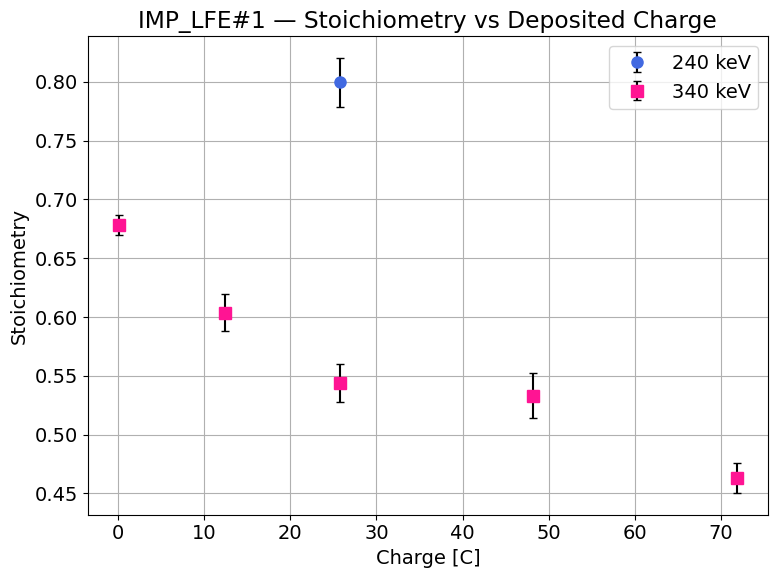

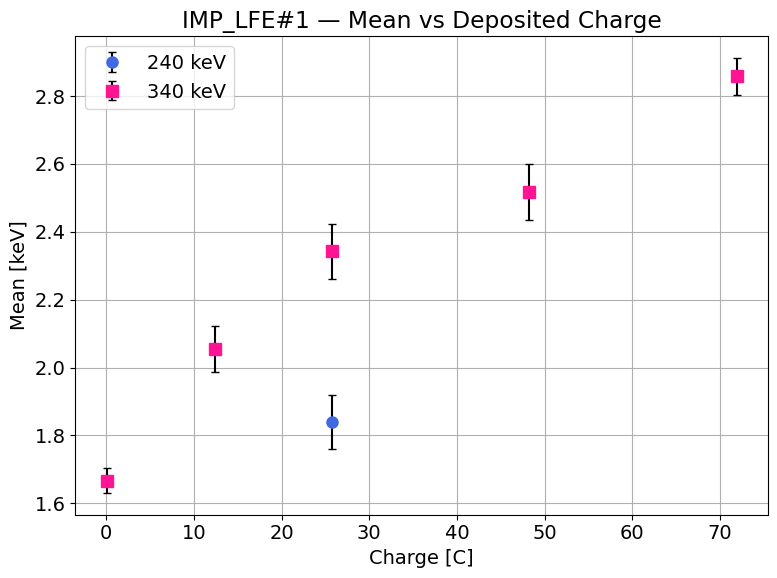

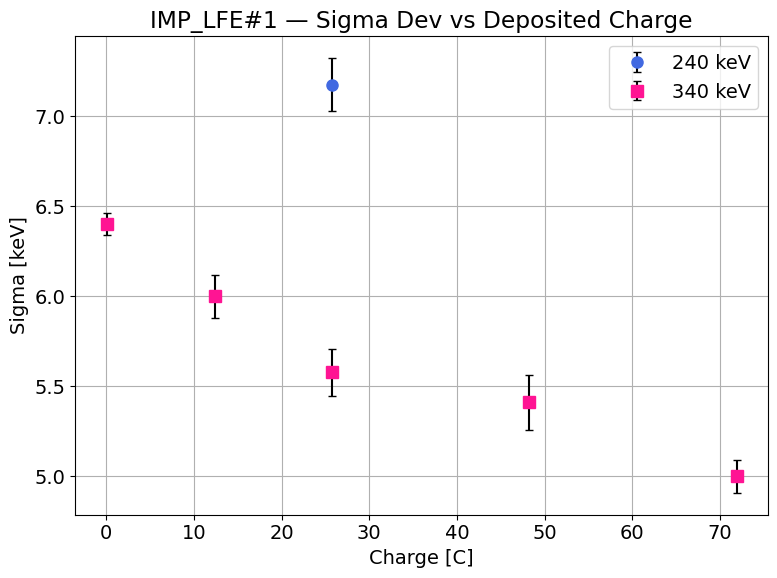

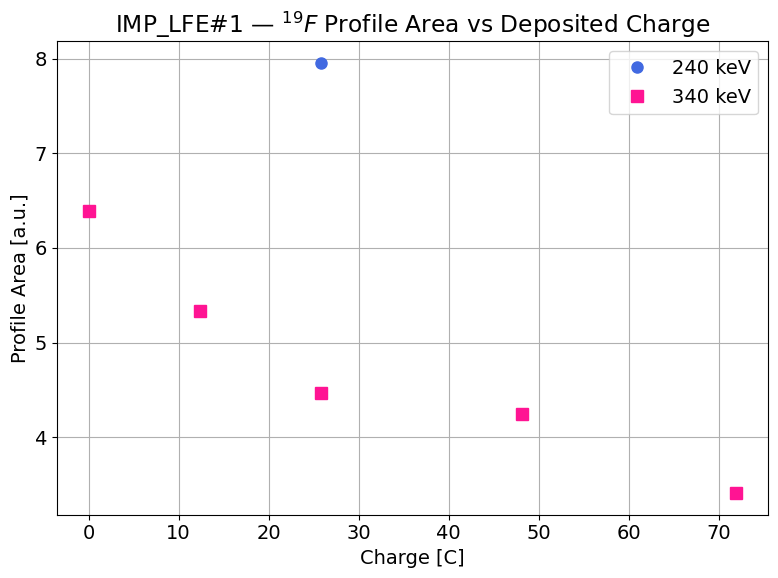

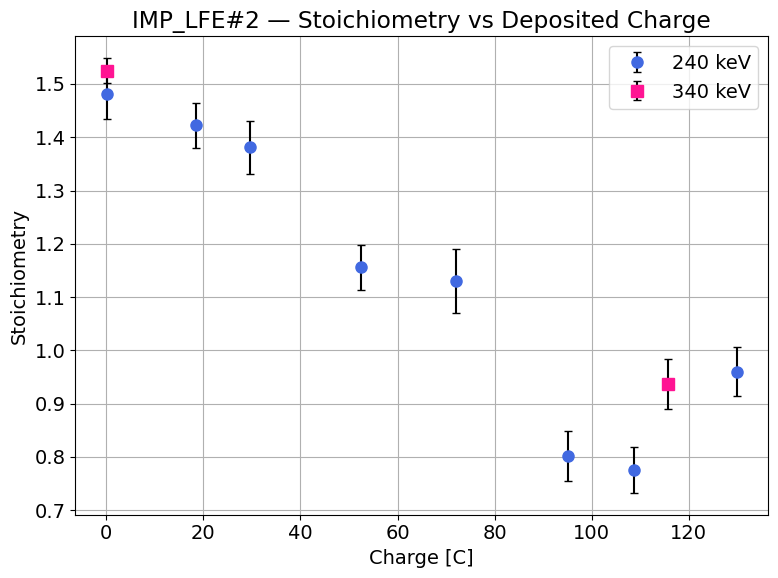

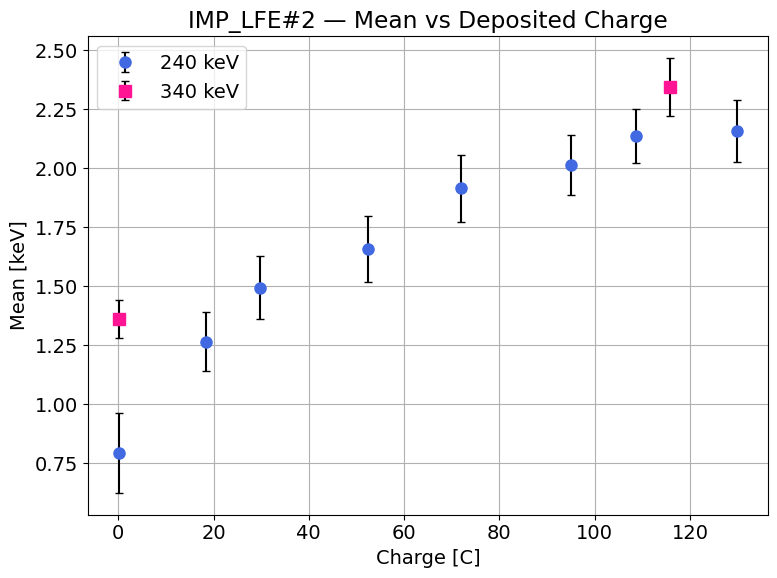

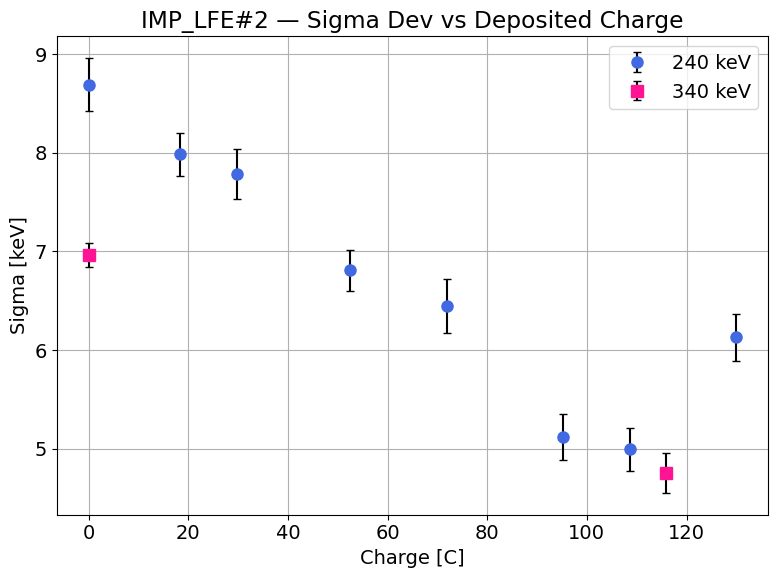

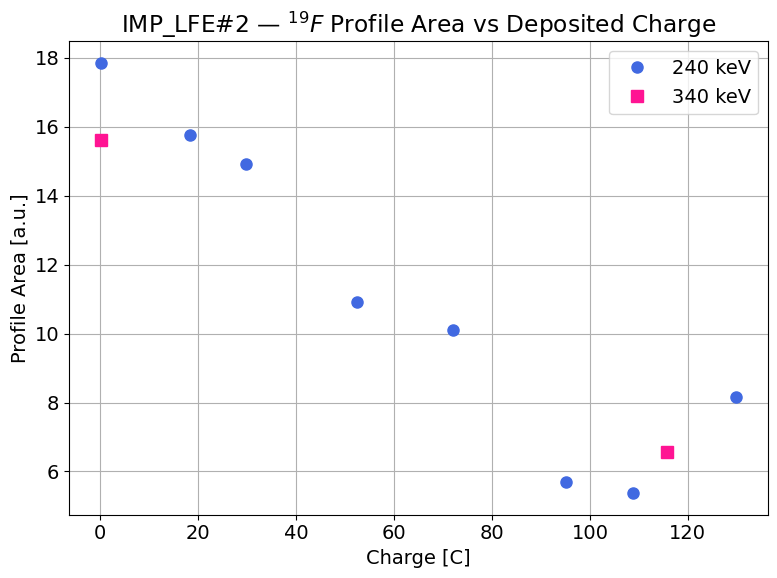

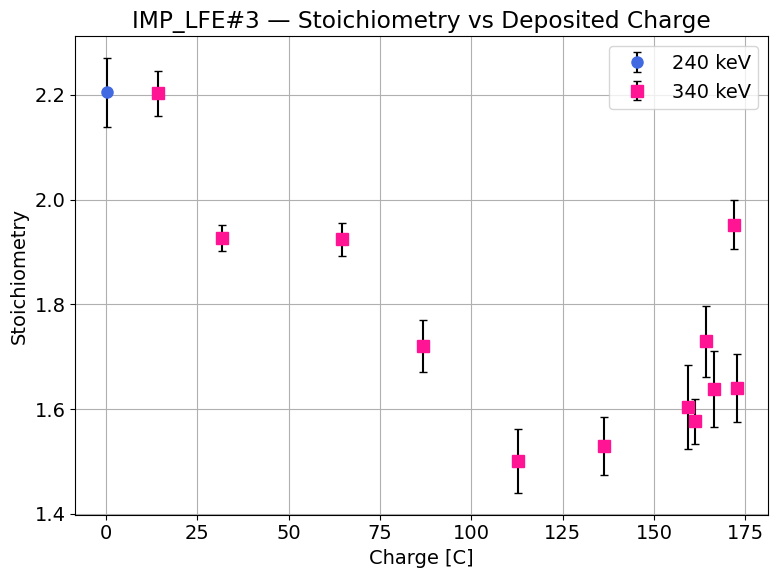

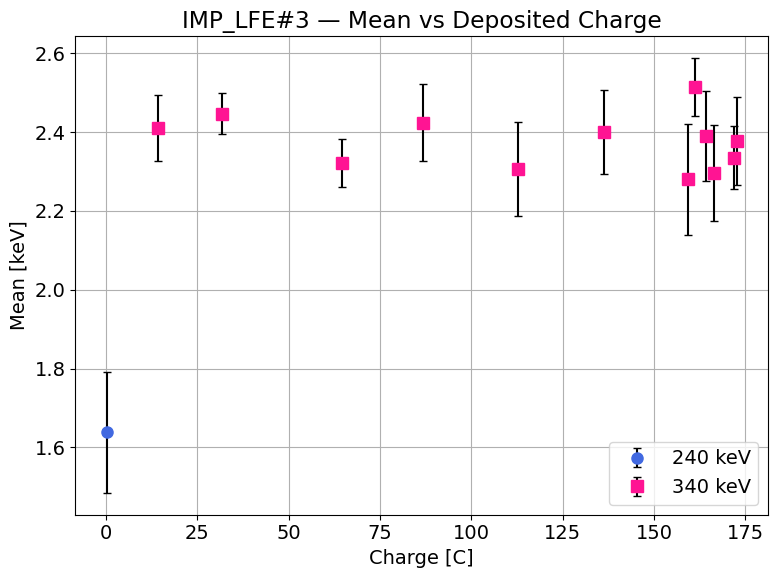

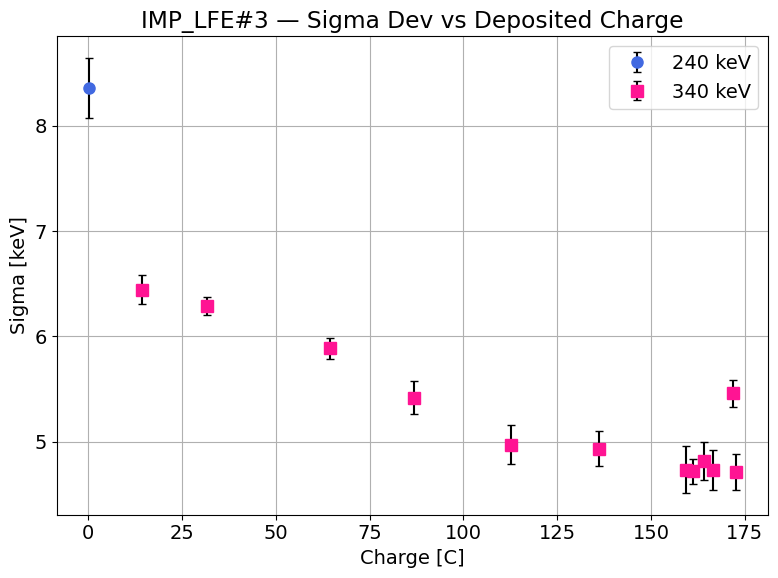

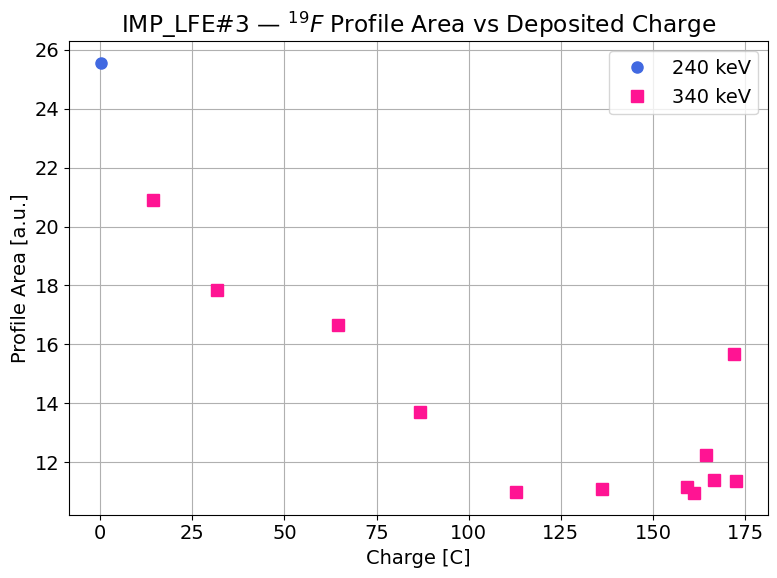

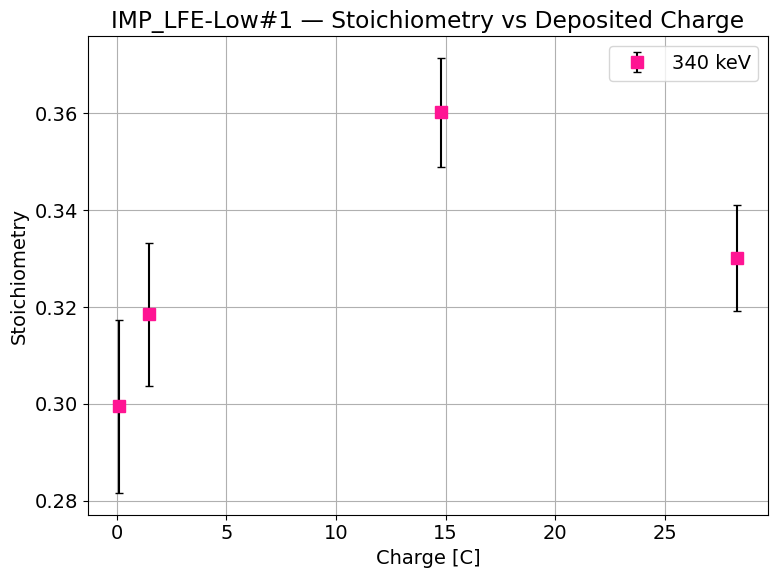

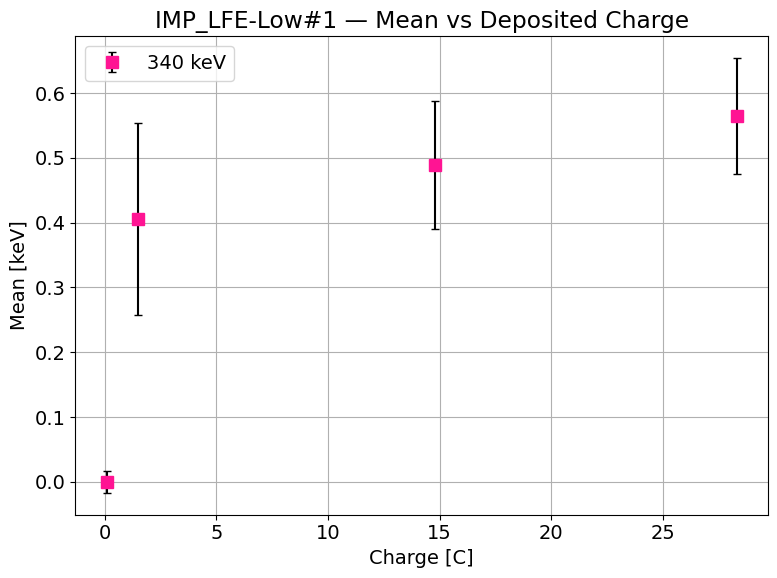

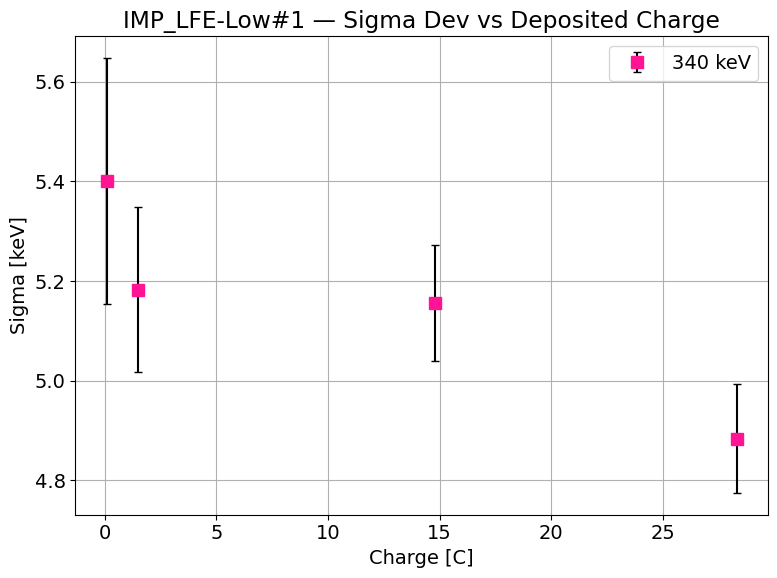

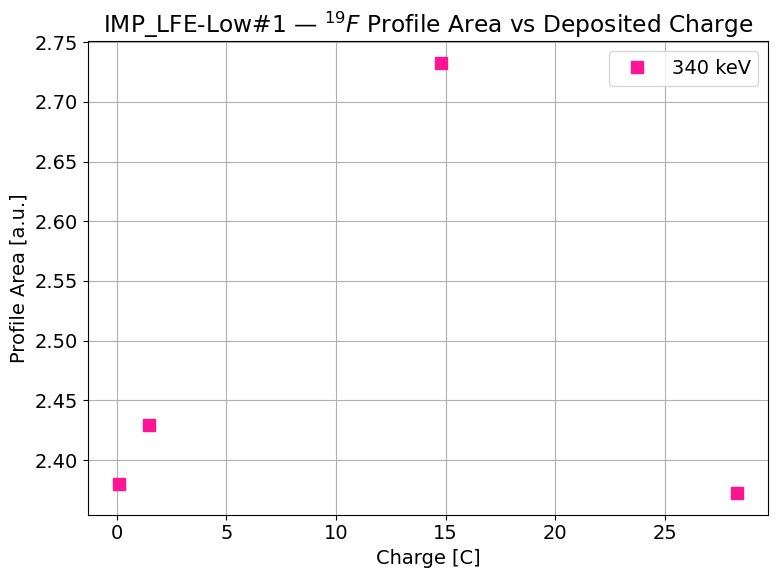

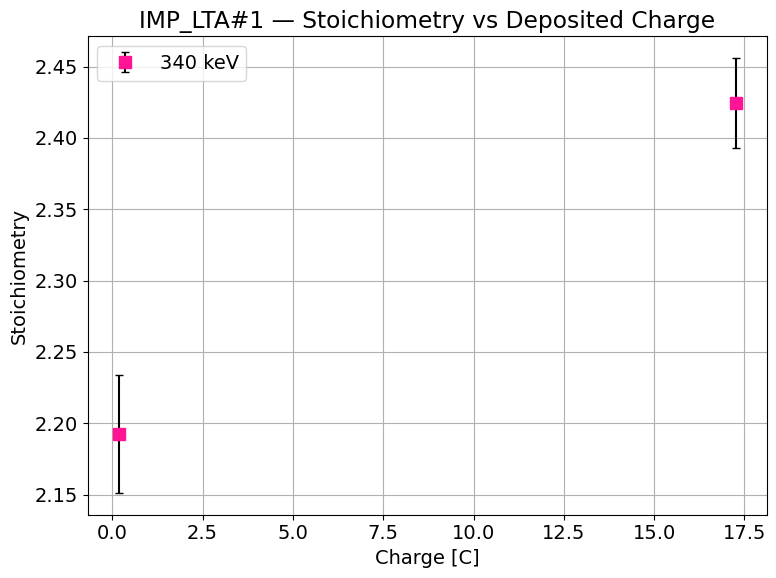

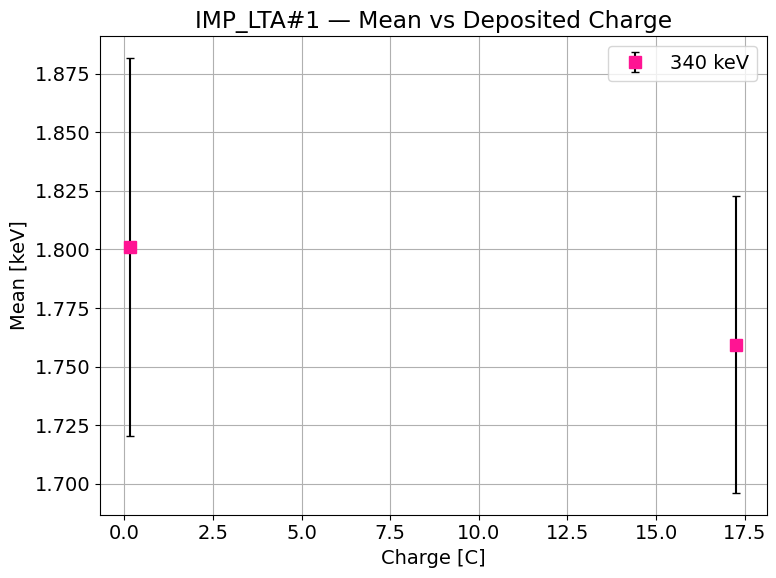

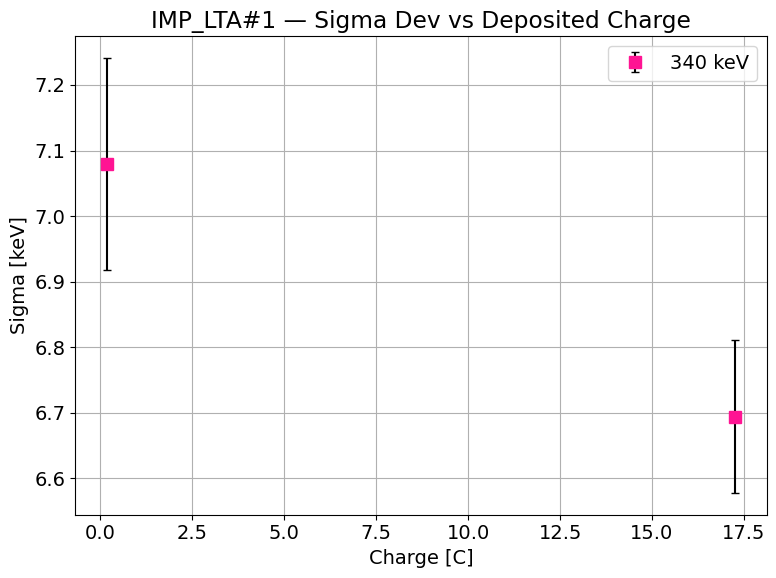

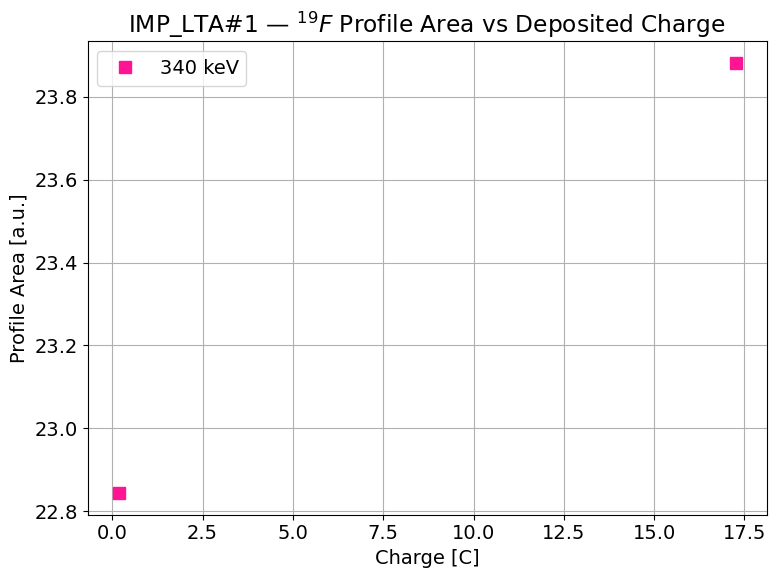

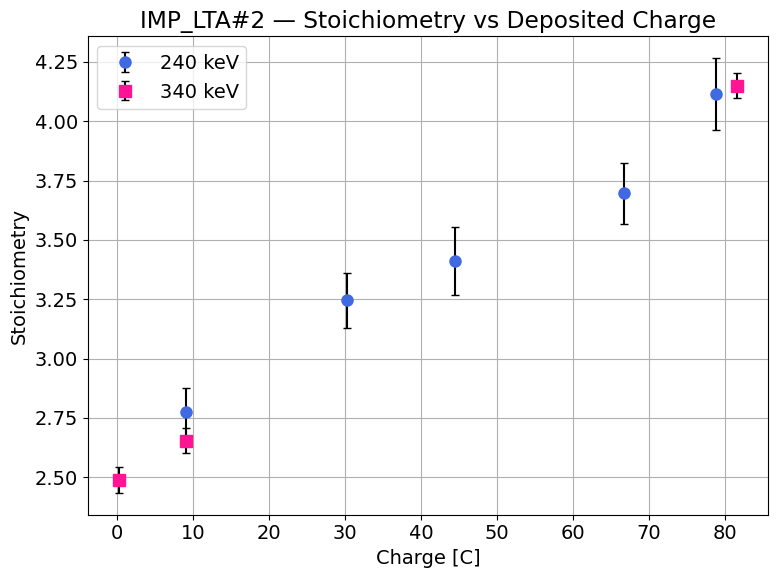

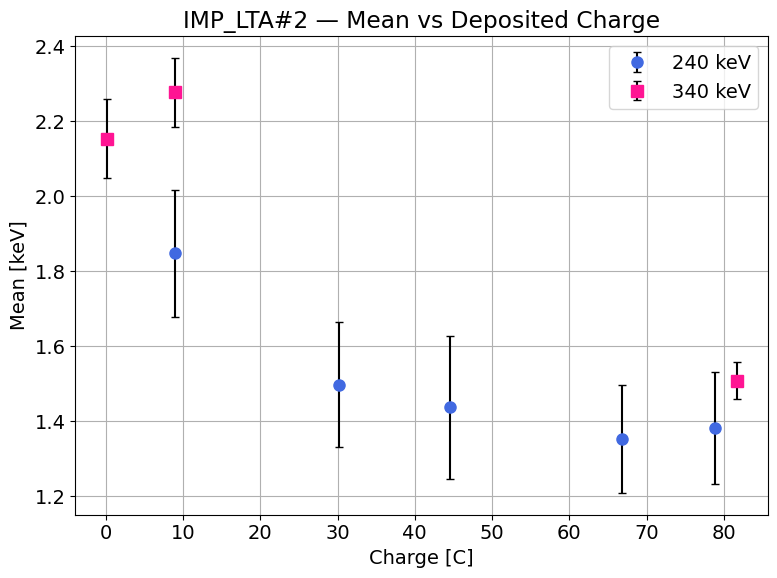

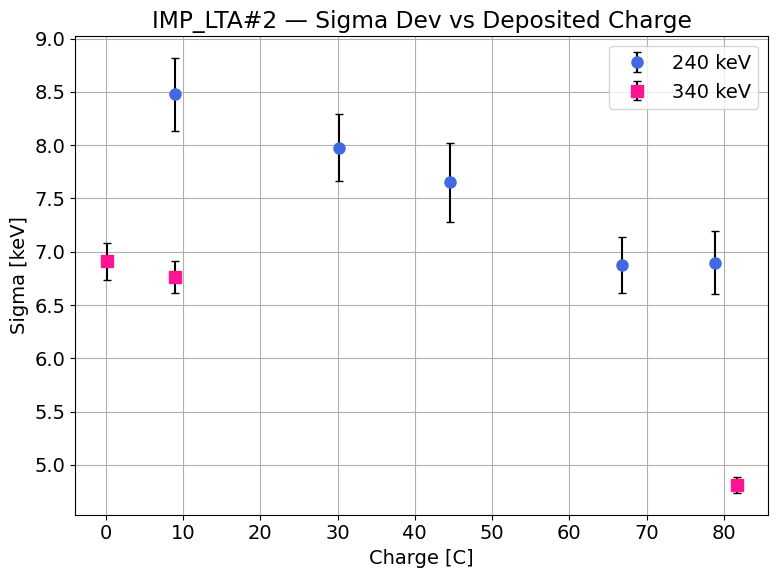

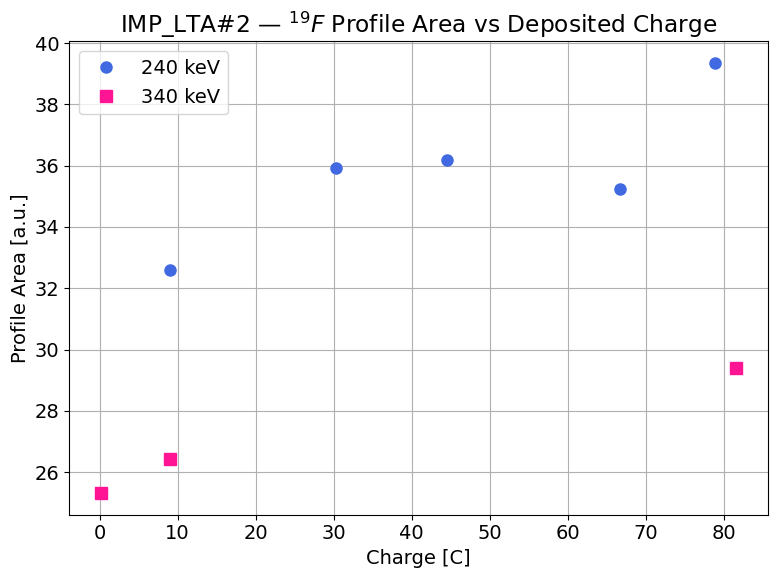

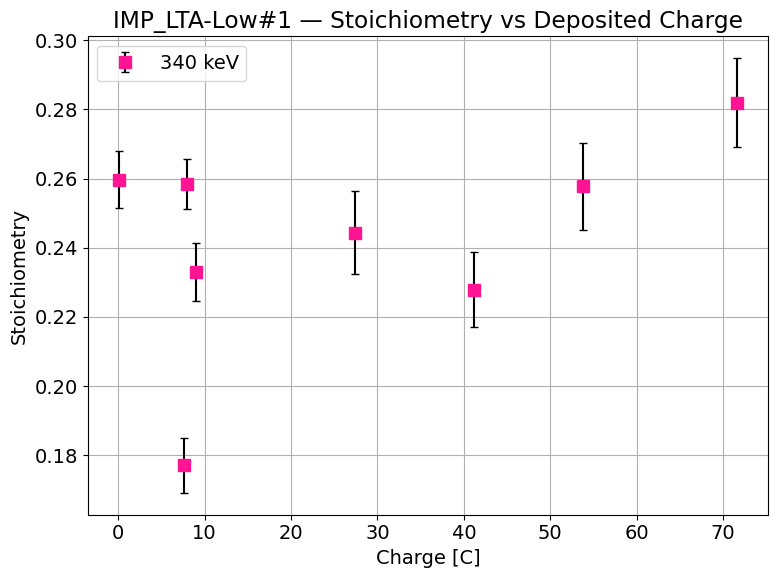

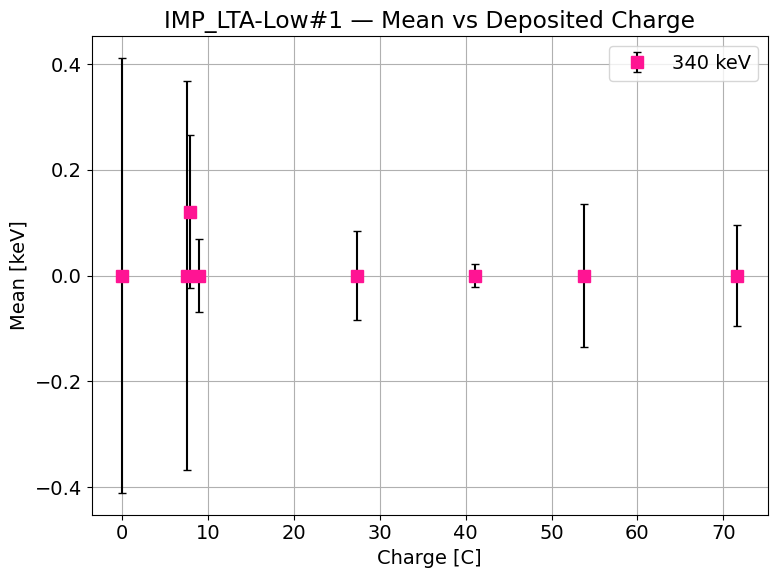

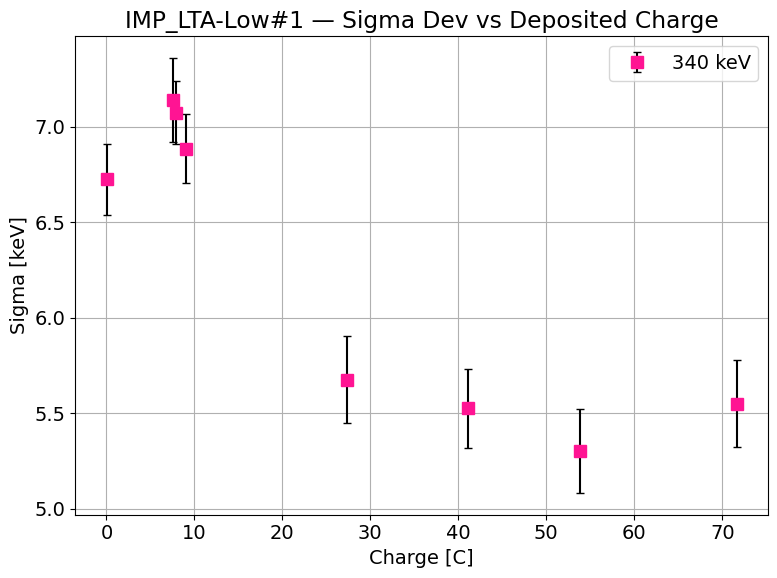

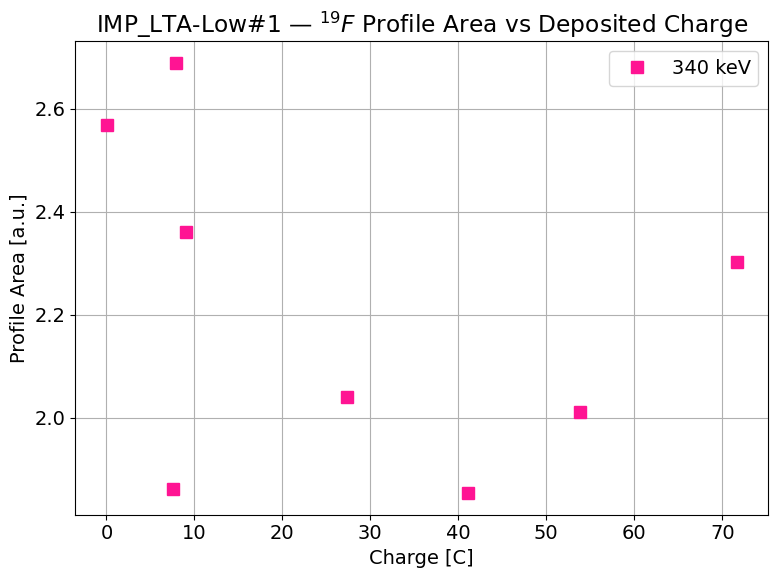

In [26]:
from random import gauss
import re

from matplotlib.dviread import find_tex_file
from numpy import size

def build_charge_map(df_params, excel_path="/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx"):
    charge_map = {}  # (target, scan) -> charge_C
    for target in df_params['target'].unique():
        # find sheet containing target
        sheet_found = None
        for sheet in ['Beamtime 1', 'Beamtime 2', 'Beamtime 3', 'Beamtime 4']:
            df_sheet = pd.read_excel(excel_path, sheet_name=sheet)
            if target in df_sheet['Target'].values:
                sheet_found = sheet
                df_sheet_target = df_sheet[df_sheet['Target'] == target]
                break
        if sheet_found is None:
            print(f"No sheet for {target}, skipping")
            continue

        # scans in sheet
        run_types = df_sheet_target['Run Type'].dropna().astype(str).unique()
        scans = [rt for rt in run_types if re.match(r'^Scan\s*\d+$', rt)]
        scans.sort(key=lambda s: int(re.search(r'\d+', s).group())) if scans else scans

        # build runs per scan (list of lists)
        run_lists = []
        for scan in scans:
            df_temp = df_sheet_target[(df_sheet_target["Target"] == target) & (df_sheet_target["Run Type"] == scan)]
            run_lists.append(df_temp['Run Number'].astype(int).tolist())

        # compute total deposited charge per scan (same Profiler logic)
        charge_tot = []
        for i, scan in enumerate(scans):
            run0 = run_lists[0][0]
            run1 = run_lists[i][-1]
            temp = 0.0
            for run in range(run0, run1 + 1):
                try:
                    usecol = 1 if sheet_found != 'Beamtime 4' else 2
                    time, current = np.genfromtxt(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/CURRENT/run{run}.txt", usecols=(0, usecol), unpack=True)
                except Exception:
                    continue
                time_diff = np.diff(np.insert(time, 0, 0))
                mask = current > 0
                if mask.any():
                    total_charge = np.sum(current[mask] * time_diff[mask])
                    temp += total_charge
            charge_tot.append(temp)

        df_map = pd.DataFrame({'scan': scans, 'charge_uC': charge_tot})
        df_map['charge_C'] = df_map['charge_uC'] / 1e6

        # fill mapping for scans present in df_params for this target
        for scan in scans:
            c = df_map.loc[df_map['scan'] == scan, 'charge_C']
            if not c.empty:
                charge_map[(target, scan)] = float(c.values[0])
    return charge_map

def extract_quantities(csv_path, excel_path="/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx"):
    df_params_local = pd.read_csv(csv_path)
    charge_map = build_charge_map(df_params_local, excel_path=excel_path)
    charges, stoichs, stoich_errs, mus, mus_errs, sigmas, sigmas_errs = [], [], [], [], [], [], []
    for _, row in df_params_local.iterrows():
        key = (row['target'], row['scan'])
        if key in charge_map:
            charges.append(charge_map[key])
            # recover errors if present (column names like n_backing_error, mean_error, std_error)
            stoichs.append(row['n_backing'])
            stoich_errs.append(row.get('n_backing_error', 0.0))
            mus.append(row.get('mean', np.nan))
            mus_errs.append(row.get('mean_error', 0.0))
            sigmas.append(row.get('std', np.nan))
            sigmas_errs.append(row.get('std_error', 0.0))
        else:
            continue
    return (np.array(charges), np.array(stoichs), np.array(stoich_errs),
            np.array(mus), np.array(mus_errs), np.array(sigmas), np.array(sigmas_errs))

# read parameter tables
df240 = pd.read_csv('results/fit_params_240.csv')
df340 = pd.read_csv('results/fit_params_340.csv')

# build one charge map covering both sets
charge_map = build_charge_map(pd.concat([df240, df340], ignore_index=True))

# per-target plots mixing 240 and 340 scans (one figure per target), with errors from XXX_error columns
targets = sorted(set(df240['target']).union(df340['target']))
for target in targets:
    # collect 240 data for this target
    df_t240 = df240[df240['target'] == target]
    q240, s240, s240_err, mu240, mu240_err, sigma240, sigma240_err, alpha240, alpha240_err = [], [], [], [], [], [], [], [], []
    for _, r in df_t240.iterrows():
        key = (target, r['scan'])
        if key in charge_map:
            q240.append(charge_map[key])
            s240.append(r['n_backing'])
            s240_err.append(r.get('n_backing_error', 0.0))
            mu240.append(r.get('mean', np.nan))
            mu240_err.append(r.get('mean_error', 0.0))
            sigma240.append(r.get('std', np.nan))
            sigma240_err.append(r.get('std_error', 0.0))
            alpha240.append(r.get('alpha', np.nan))
            alpha240_err.append(r.get('alpha_error', 0.0))

    # collect 340 data for this target
    df_t340 = df340[df340['target'] == target]
    q340, s340, s340_err, mu340, mu340_err, sigma340, sigma340_err, alpha340, alpha340_err = [], [], [], [], [], [], [], [], []
    for _, r in df_t340.iterrows():
        key = (target, r['scan'])
        if key in charge_map:
            q340.append(charge_map[key])
            s340.append(r['n_backing'])
            s340_err.append(r.get('n_backing_error', 0.0))
            mu340.append(r.get('mean', np.nan))
            mu340_err.append(r.get('mean_error', 0.0))
            sigma340.append(r.get('std', np.nan))
            sigma340_err.append(r.get('std_error', 0.0))
            alpha340.append(r.get('alpha', np.nan))
            alpha340_err.append(r.get('alpha_error', 0.0))

    if not (q240 or q340):
        continue  # nothing to plot

    plt.figure(figsize=(8,6))
    if q240:
        plt.errorbar(q240, s240, yerr=s240_err, fmt='o', markersize=8, color='royalblue', ecolor='black', label='240 keV', capsize=3, linestyle='None')
    if q340:
        plt.errorbar(q340, s340, yerr=s340_err, fmt='s', markersize=8, color='deeppink',  ecolor='black', label='340 keV', capsize=3, linestyle='None')
    plt.xlabel('Charge [C]')
    plt.ylabel('Stoichiometry')
    plt.title(f'{target} — Stoichiometry vs Deposited Charge')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'results/{target}_stoichiometry_vs_charge.png')
    plt.show()

    plt.figure(figsize=(8,6))
    if q240:
        plt.errorbar(q240, mu240, yerr=mu240_err, fmt='o', markersize=8, color='royalblue', ecolor='black', label='240 keV', capsize=3, linestyle='None')
    if q340:
        plt.errorbar(q340, mu340, yerr=mu340_err, fmt='s', markersize=8, color='deeppink',  ecolor='black', label='340 keV', capsize=3, linestyle='None')
    plt.xlabel('Charge [C]')
    plt.ylabel('Mean [keV]')
    plt.title(f'{target} — Mean vs Deposited Charge')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'results/{target}_mean_vs_charge.png')
    plt.show()

    plt.figure(figsize=(8,6))
    if q240:
        plt.errorbar(q240, sigma240, yerr=sigma240_err, fmt='o', markersize=8, color='royalblue', ecolor='black', label='240 keV', capsize=3, linestyle='None')
    if q340:
        plt.errorbar(q340, sigma340, yerr=sigma340_err, fmt='s', markersize=8, color='deeppink',  ecolor='black', label='340 keV', capsize=3, linestyle='None')
    plt.xlabel('Charge [C]')
    plt.ylabel('Sigma [keV]')
    plt.title(f'{target} — Sigma Dev vs Deposited Charge')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'results/{target}_sigma_vs_charge.png')
    plt.show()


    plt.figure(figsize=(8,6))
    if q240:
        area = []
        idxs = np.arange(len(q240))
        for idx in idxs:
            grid = np.linspace(-10, 60, 1000)
            area.append(skewed_gaussian(grid, mu240[idx], sigma240[idx], alpha240[idx]).sum() * (grid[1]-grid[0])*s240[idx])
        plt.errorbar(q240, area, fmt='o', markersize=8, color='royalblue', ecolor='black', label='240 keV', capsize=3, linestyle='None')
    if q340:
        area = []
        idxs = np.arange(len(q340))
        for idx in idxs:
            grid = np.linspace(-10, 60, 1000)
            area.append(skewed_gaussian(grid, mu340[idx], sigma340[idx], alpha340[idx]).sum() * (grid[1]-grid[0])*s340[idx])
        plt.errorbar(q340, area, fmt='s', markersize=8, color='deeppink',  ecolor='black', label='340 keV', capsize=3, linestyle='None')
    plt.xlabel('Charge [C]')
    plt.ylabel('Profile Area [a.u.]')
    plt.title(fr'{target} — ${{}}^{{19}}F$ Profile Area vs Deposited Charge')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()